# Lecture 5 — Class Exercise - Dennis Sebastian
## Distribution Charts: Airbnb London



In [4]:
import pandas as pd
import plotly.express as px
import numpy as np

# Dataset: Airbnb London Listings

df = pd.read_csv("airbnb_london.csv")
print(f"Loaded: {len(df)} listings")
print(df.describe().round(1))

Loaded: 2500 listings
        price  minimum_nights  number_of_reviews  availability_365  \
count  2500.0          2500.0             2500.0            2500.0   
mean    148.6            14.8              147.9             183.7   
std     110.9             8.4               86.3             105.5   
min      20.5             1.0                0.0               0.0   
25%      71.7             8.0               74.0              92.0   
50%     117.5            15.0              145.0             182.0   
75%     188.9            22.0              222.2             277.0   
max    1032.4            29.0              299.0             364.0   

       reviews_per_month  
count             2500.0  
mean                 2.0  
std                  2.0  
min                  0.0  
25%                  0.6  
50%                  1.4  
75%                  2.8  
max                 15.2  


In [5]:
p95 = df['price'].quantile(0.95)
df_cap = df[df['price'] <= p95]
print(f"95th percentile price: £{p95:.0f}")
print(df_cap.groupby('room_type')['price'].describe().round(1))

95th percentile price: £373
                  count   mean   std   min    25%    50%    75%    max
room_type                                                             
Entire home/apt  1251.0  176.3  75.7  28.0  119.6  163.4  223.5  372.6
Private room      942.0   87.3  39.5  20.9   59.0   78.6  106.0  277.9
Shared room       182.0   46.3  14.1  20.5   36.8   44.1   54.3   92.8


## Task 1 — Histogram: price by room type (overlapping distributions)

**What to build:** A histogram showing price distributions for **Entire home/apt vs Private room** (exclude Shared room — too few observations) overlaid on the same chart.

**Requirements:**
- Both room types on the same chart (use `color='room_type'`)
- `barmode='overlay'` with `opacity=0.6` so both distributions are visible
- A vertical line for the median of EACH room type, differently coloured
- Insight title comparing the two distributions

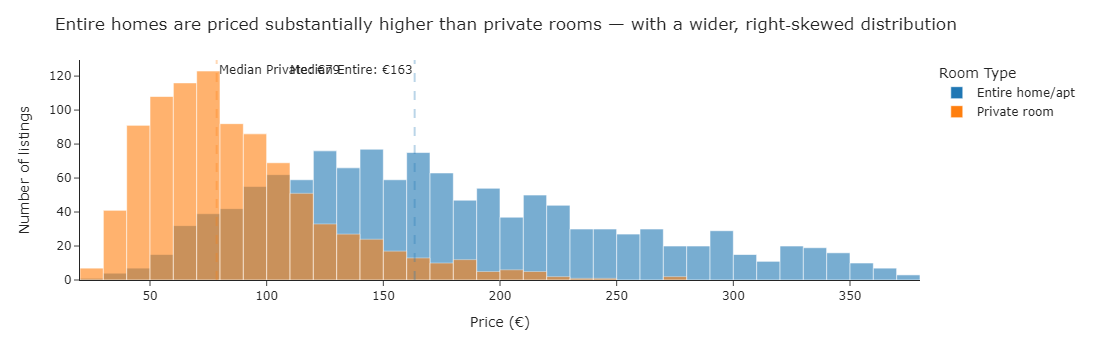

In [6]:
import plotly.graph_objects as go

# Filter only the two required room types
df_hist = df_cap[df_cap['room_type'].isin(['Entire home/apt', 'Private room'])]

# Compute medians
median_entire = df_hist[df_hist['room_type'] == 'Entire home/apt']['price'].median()
median_private = df_hist[df_hist['room_type'] == 'Private room']['price'].median()

# Base histogram
fig = px.histogram(
    df_hist,
    x='price',
    color='room_type',
    nbins=60,
    opacity=0.6,
    barmode='overlay',
    color_discrete_map={
        'Entire home/apt': '#1f77b4',
        'Private room': '#ff7f0e'
    }
)

# Add median lines
fig.add_vline(
    x=median_entire,
    line_width=2,
    line_dash='dash',
    line_color='#1f77b4',
    annotation_text=f"Median Entire: €{median_entire:.0f}",
    annotation_position="top left"
)

fig.add_vline(
    x=median_private,
    line_width=2,
    line_dash='dash',
    line_color='#ff7f0e',
    annotation_text=f"Median Private: €{median_private:.0f}",
    annotation_position="top right"
)

# Insight-driven title
fig.update_layout(
    title=(
        "Entire homes are priced substantially higher than private rooms — "
        "with a wider, right‑skewed distribution"
    ),
    xaxis_title="Price (€)",
    yaxis_title="Number of listings",
    legend_title="Room Type",
    template="simple_white"
)

fig.show()


## Task 2 — Box plot: listing activity by borough

**What to build:** A **horizontal box plot** comparing listing activity (reviews per month) across London boroughs — reviews per month is a proxy for how frequently a listing is booked.

**Requirements:**
- Horizontal orientation (borough names are long)
- Sorted by median reviews per month (most active at top)
- Highlight the **two most active** boroughs in a different colour
- Outliers shown as individual points
- Insight title naming the two busiest boroughs



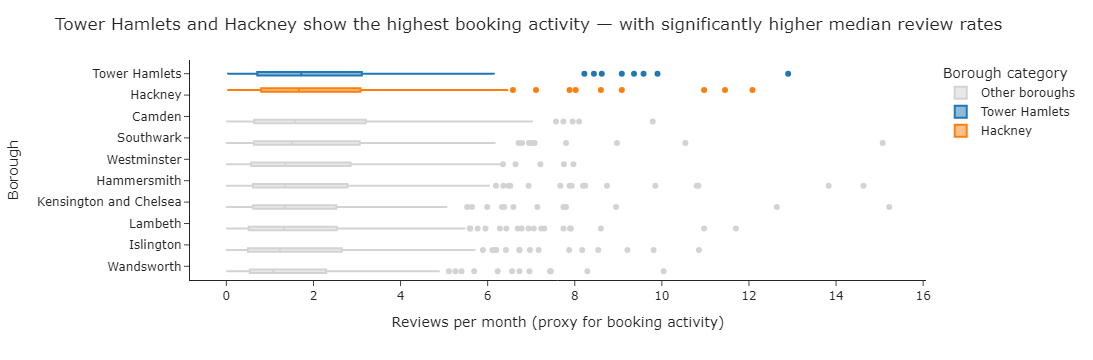

In [7]:
# Filter out listings with zero reviews per month
df_box = df_cap[df_cap['reviews_per_month'] > 0].copy()

# Compute median reviews per month per borough
borough_medians = (
    df_box.groupby('neighbourhood')['reviews_per_month']
    .median()
    .sort_values(ascending=False)
)

# Identify the two most active boroughs
top2 = borough_medians.index[:2].tolist()

# Add a column to highlight top boroughs
df_box['highlight'] = df_box['neighbourhood'].apply(
    lambda x: x if x in top2 else 'Other boroughs'
)

# Custom colors: highlight top 2, grey for others
color_map = {
    top2[0]: '#1f77b4',
    top2[1]: '#ff7f0e',
    'Other boroughs': 'lightgrey'
}

# Build the box plot
fig = px.box(
    df_box,
    x='reviews_per_month',
    y='neighbourhood',
    color='highlight',
    orientation='h',
    points='outliers',
    category_orders={'neighbourhood': borough_medians.index.tolist()},
    color_discrete_map=color_map
)

# Insight-driven title
fig.update_layout(
    title=(
        f"{top2[0]} and {top2[1]} show the highest booking activity — "
        "with significantly higher median review rates"
    ),
    xaxis_title="Reviews per month (proxy for booking activity)",
    yaxis_title="Borough",
    legend_title="Borough category",
    template="simple_white"
)

fig.show()
